In [196]:
# import packages
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [197]:
# create dataframe with housing info and verify data import
df = pd.read_csv("D600 Task 1 Dataset 1 Housing Information.csv")
df.head()

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0


In [198]:
# slice the required columns for analysis into new dataframe
newdf = df[['Price','SquareFootage', 'BackyardSpace', 'CrimeRate', 'Fireplace', 'Garage']].copy()
newdf.head()

,Price,SquareFootage,BackyardSpace,CrimeRate,Fireplace,Garage
0,255614.8992,566.62,779.42,20.56,Yes,No
1,155586.0947,1472.34,656.13,15.62,No,No
2,131050.8324,550.00,754.57,12.47,Yes,Yes
3,151361.7125,941.81,439.59,22.22,Yes,No
4,113167.6128,550.00,353.03,8.28,No,Yes


In [199]:
# describe Price
newdf['Price'].describe()

count    7.000000e+03
mean     3.072820e+05
std      1.501734e+05
min      8.500000e+04
25%      1.921075e+05
50%      2.793230e+05
75%      3.918781e+05
max      1.046676e+06
Name: Price, dtype: float64

In [200]:
# describe SquareFootage
newdf['SquareFootage'].describe()

count    7000.000000
mean     1048.947459
std       426.010482
min       550.000000
25%       660.815000
50%       996.320000
75%      1342.292500
max      2874.700000
Name: SquareFootage, dtype: float64

In [201]:
# describe BackyardSpace
newdf['BackyardSpace'].describe()

count    7000.000000
mean      511.507029
std       279.926549
min         0.390000
25%       300.995000
50%       495.965000
75%       704.012500
max      1631.360000
Name: BackyardSpace, dtype: float64

In [202]:
# describe CrimeRate
newdf['CrimeRate'].describe()

count    7000.000000
mean       31.226194
std        18.025327
min         0.030000
25%        17.390000
50%        30.385000
75%        43.670000
max        99.730000
Name: CrimeRate, dtype: float64

In [203]:
# describe Fireplace
newdf['Fireplace'].describe()

count     7000
unique       2
top         No
freq      5172
Name: Fireplace, dtype: object

In [204]:
# create Fireplace frequency table and print
fireplace_counts = newdf['Fireplace'].value_counts()
print(fireplace_counts)

Fireplace
No     5172
Yes    1828
Name: count, dtype: int64


In [205]:
# describe Garage
newdf['Garage'].describe()

count     7000
unique       2
top         No
freq      4488
Name: Garage, dtype: object

In [206]:
# create Garage frequency table and print
garage_counts = newdf['Garage'].value_counts()
print(garage_counts)

Garage
No     4488
Yes    2512
Name: count, dtype: int64


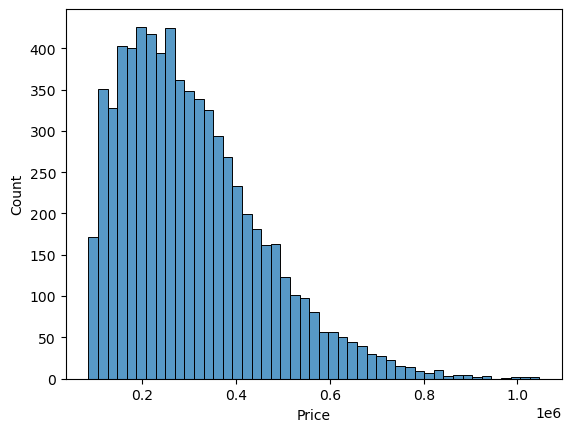

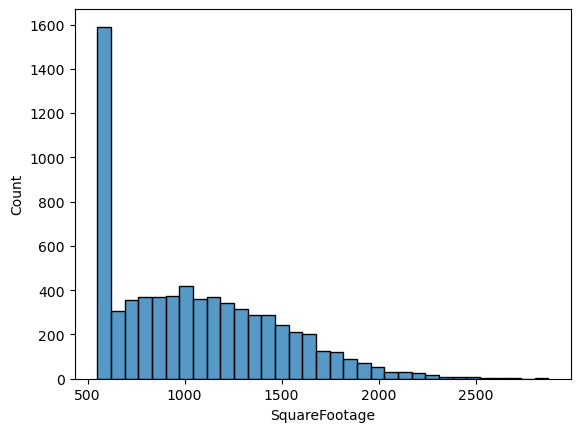

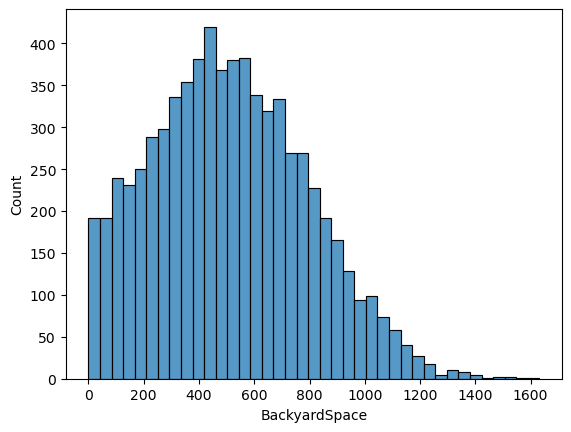

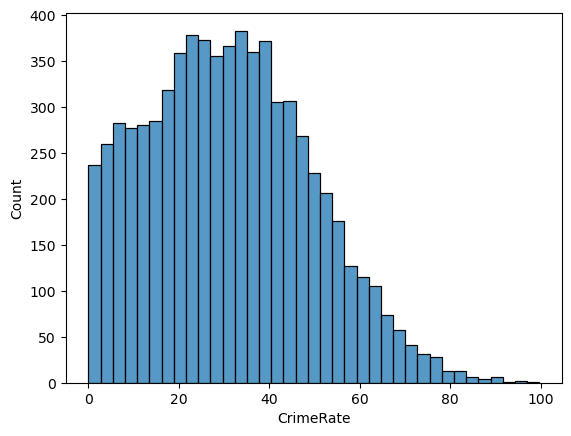

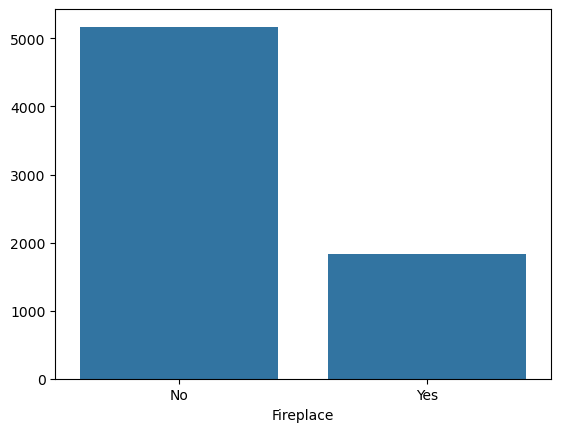

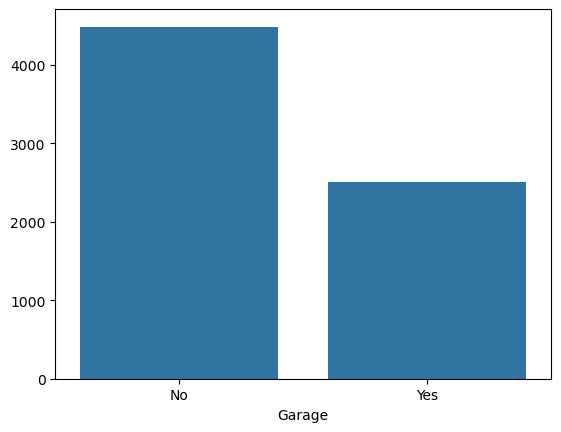

In [207]:
# create univariate visualizations of the variables
sns.histplot(newdf['Price'])
plt.show()
sns.histplot(newdf['SquareFootage'])
plt.show()
sns.histplot(newdf['BackyardSpace'])
plt.show()
sns.histplot(newdf['CrimeRate'])
plt.show()
sns.barplot(x = fireplace_counts.index, y = fireplace_counts.values)
plt.show()
sns.barplot(x = garage_counts.index, y = garage_counts.values)
plt.show()

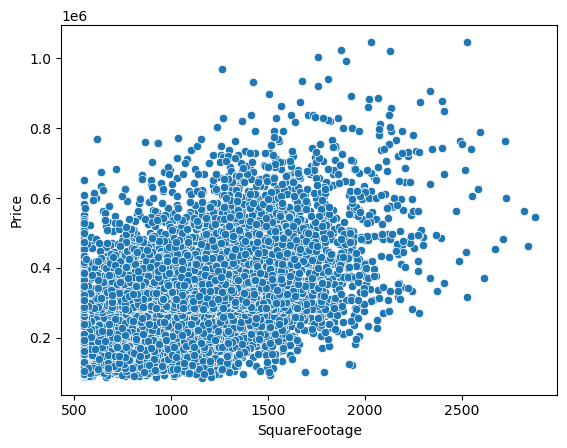

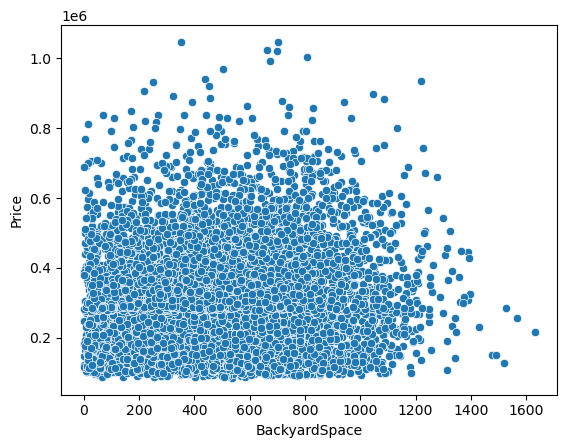

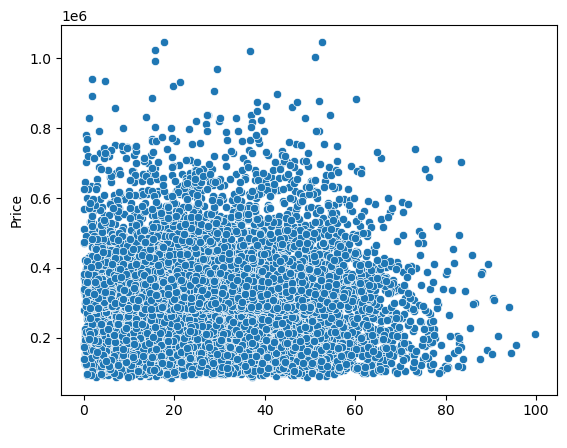

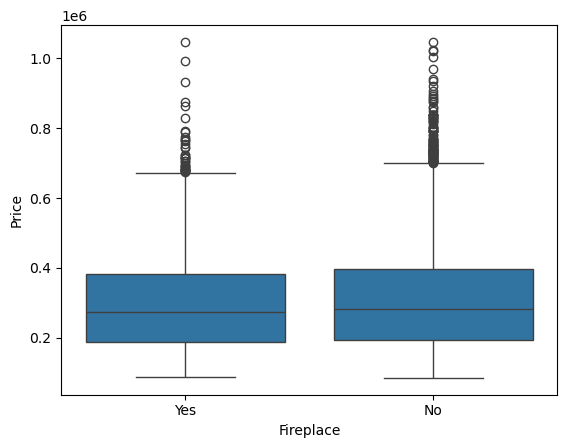

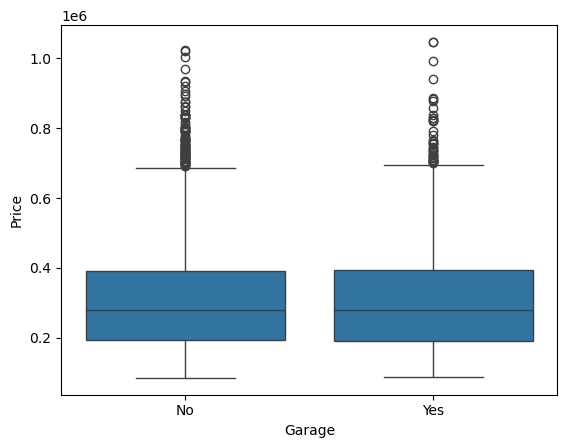

In [208]:
# create bivariate visualizations of the variables
sns.scatterplot(x = 'SquareFootage', y = 'Price', data = newdf)
plt.show()
sns.scatterplot(x = 'BackyardSpace', y = 'Price', data = newdf)
plt.show()
sns.scatterplot(x = 'CrimeRate', y = 'Price', data = newdf)
plt.show()
sns.boxplot(x = 'Fireplace', y = 'Price', data = newdf)
plt.show()
sns.boxplot(x = 'Garage', y = 'Price', data = newdf)
plt.show()

In [209]:
# create dummy variables for Fireplace and Garage
newdf['Fireplace_Present'] = newdf['Fireplace'].map({'Yes': 1, 'No': 0})
newdf['Garage_Present'] = newdf['Garage'].map({'Yes': 1, 'No': 0})
print(newdf)

            Price  SquareFootage  BackyardSpace  CrimeRate Fireplace Garage  \
0     255614.8992         566.62         779.42      20.56       Yes     No   
1     155586.0947        1472.34         656.13      15.62        No     No   
2     131050.8324         550.00         754.57      12.47       Yes    Yes   
3     151361.7125         941.81         439.59      22.22       Yes     No   
4     113167.6128         550.00         353.03       8.28        No    Yes   
...           ...            ...            ...        ...       ...    ...   
6995  307821.1758         550.00         892.35      11.89        No    Yes   
6996  421368.8869        1726.12         943.19      34.06        No    Yes   
6997  473382.5348        1026.36         149.31       0.10        No     No   
6998  343397.9756        2218.22         526.81      11.18        No    Yes   
6999  438060.8193        1553.57         844.06      18.80        No    Yes   

      Fireplace_Present  Garage_Present  
0        

In [210]:
# add constant and then split the data using 80/20
newdf['constant'] = 1
train_df, test_df = train_test_split(newdf, test_size = 0.2, random_state = 42)

# show the shapes
print('Training dataset: ', train_df.shape)
print('Test dataset: ', test_df.shape)

# export the datasets to csv files
train_df.to_csv('Training Dataset.csv', index = False)
test_df.to_csv('Test Dataset.csv', index = False)

Training dataset:  (5600, 9)
Test dataset:  (1400, 9)


In [211]:
# define dependent and independent variables
X_train = train_df[['SquareFootage', 'BackyardSpace', 'CrimeRate', 'Fireplace_Present', 'Garage_Present']]
y_train = train_df['Price']

# fit the regression model
model = sm.OLS(y_train, X_train).fit()

In [212]:
# optimize using backward elimination
def backward_elimination(X, y, significance_level = 0.05):
    X = sm.add_constant(X)
    while True:
        model = sm.OLS(y, X).fit()
        p_values = model.pvalues
        max_p_value = p_values.max()
        if max_p_value >= significance_level:
            X = X.drop(p_values.idxmax(), axis = 1)
        else:
            break
    return model, X

# run backward elimination
optimized_model, final_X = backward_elimination(X_train, y_train)

# get the columns kept by the model and transform X_train and X_test to keep final columns
final_columns = final_X.columns
X_train_transformed = X_train[final_columns[1:]]
X_test_transformed = X_test[final_columns[1:]]

print(optimized_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     787.3
Date:                Sun, 23 Mar 2025   Prob (F-statistic):               0.00
Time:                        13:54:07   Log-Likelihood:                -73752.
No. Observations:                5600   AIC:                         1.475e+05
Df Residuals:                    5596   BIC:                         1.475e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            1.1e+05   6190.417     17.768

In [213]:
# find the mean squared error on the training set
y_train_pred = optimized_model.predict(sm.add_constant(X_train_transformed))
mse_train = mean_squared_error(y_train, y_train_pred)
print(mse_train)

16098108983.671066


In [214]:
# run prediction on test dataset for accuracy
y_test_pred = optimized_model.predict(sm.add_constant(X_test_transformed))
mse_test = mean_squared_error(y_test, y_test_pred)
print(mse_test)

14418792950.659777


In [215]:
# calculate variance inflation factor to check for multicollinearity
vif_df = pd.DataFrame()
vif_df['Feature'] = X_train_transformed.columns
vif_df['VIF'] = [variance_inflation_factor(X_train_transformed.values, i) for i in range(X_train_transformed.shape[1])]
print(vif_df)

         Feature       VIF
0  SquareFootage  4.136361
1  BackyardSpace  3.459102
2      CrimeRate  2.923434
